# ARTI 403 – Image Processing
## Lab 2 – Image Sampling, Quantization, Arithmetic & Set/Logical Operations

**Note on images:** the original dataset (`lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`) wasn't attached to the manual, so this notebook generates equivalent standard test images into `../images/` the first time it runs (a classic grayscale portrait standing in for Lena, the real `cameraman` test image, and two overlapping shapes for the set operations). **If your lab has its own `../images/` folder with the original files, just delete/skip the generation cell below and the rest of the notebook will use your real files unchanged.**

In [1]:
import os
import numpy as np
from PIL import Image
import cv2

os.makedirs("../images", exist_ok=True)

if not os.path.exists("../images/lena_gray_256.tif"):
    from skimage import data
    cam = data.camera()
    Image.fromarray(cam).save("../images/cameraman.tif")

    astro = data.astronaut()
    astro_gray = cv2.cvtColor(astro, cv2.COLOR_RGB2GRAY)
    astro_gray = cv2.resize(astro_gray, (256, 256), interpolation=cv2.INTER_AREA)
    Image.fromarray(astro_gray).save("../images/lena_gray_256.tif")

    size = 400
    A = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(A, (170, 200), 120, 255, -1)
    B = np.zeros((size, size), dtype=np.uint8)
    cv2.rectangle(B, (150, 100), (380, 330), 255, -1)
    Image.fromarray(A).save("../images/A.png")
    Image.fromarray(B).save("../images/B.png")

    print("Sample images generated in ../images/")
else:
    print("Using existing images in ../images/")


Using existing images in ../images/


## 1) Import the libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 2) Define Functions

In [3]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()


## 3) Import the image and set the parameters

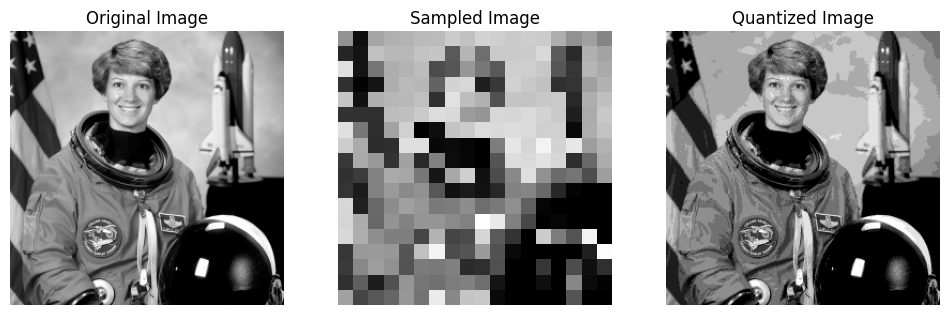

In [4]:
image_path = '../images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


## Arithmetic Operations

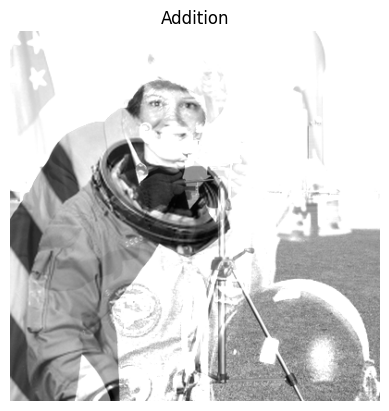

In [5]:
from PIL import Image

img1 = Image.open('../images/lena_gray_256.tif')
img2 = Image.open('../images/cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr.astype(np.int16) + im2arr.astype(np.int16)
addition = np.clip(addition, 0, 255).astype(np.uint8)
resultImage = Image.fromarray(addition)
plt.imshow(resultImage, cmap='gray'); plt.title('Addition'); plt.axis('off'); plt.show()


## Sets and Logical Operations

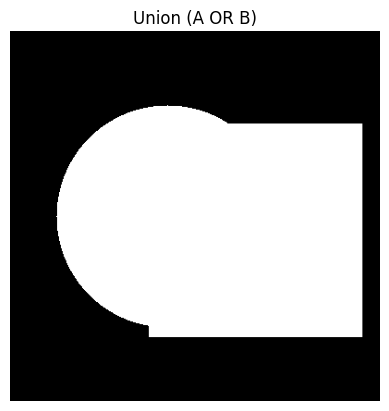

In [6]:
img3 = Image.open('../images/A.png')
img4 = Image.open('../images/B.png')

img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)
plt.imshow(resultImage2, cmap='gray'); plt.title('Union (A OR B)'); plt.axis('off'); plt.show()


---
# Practical Session Tasks

## Task #1 — Change the sampling and quantization parameters and observe the effects

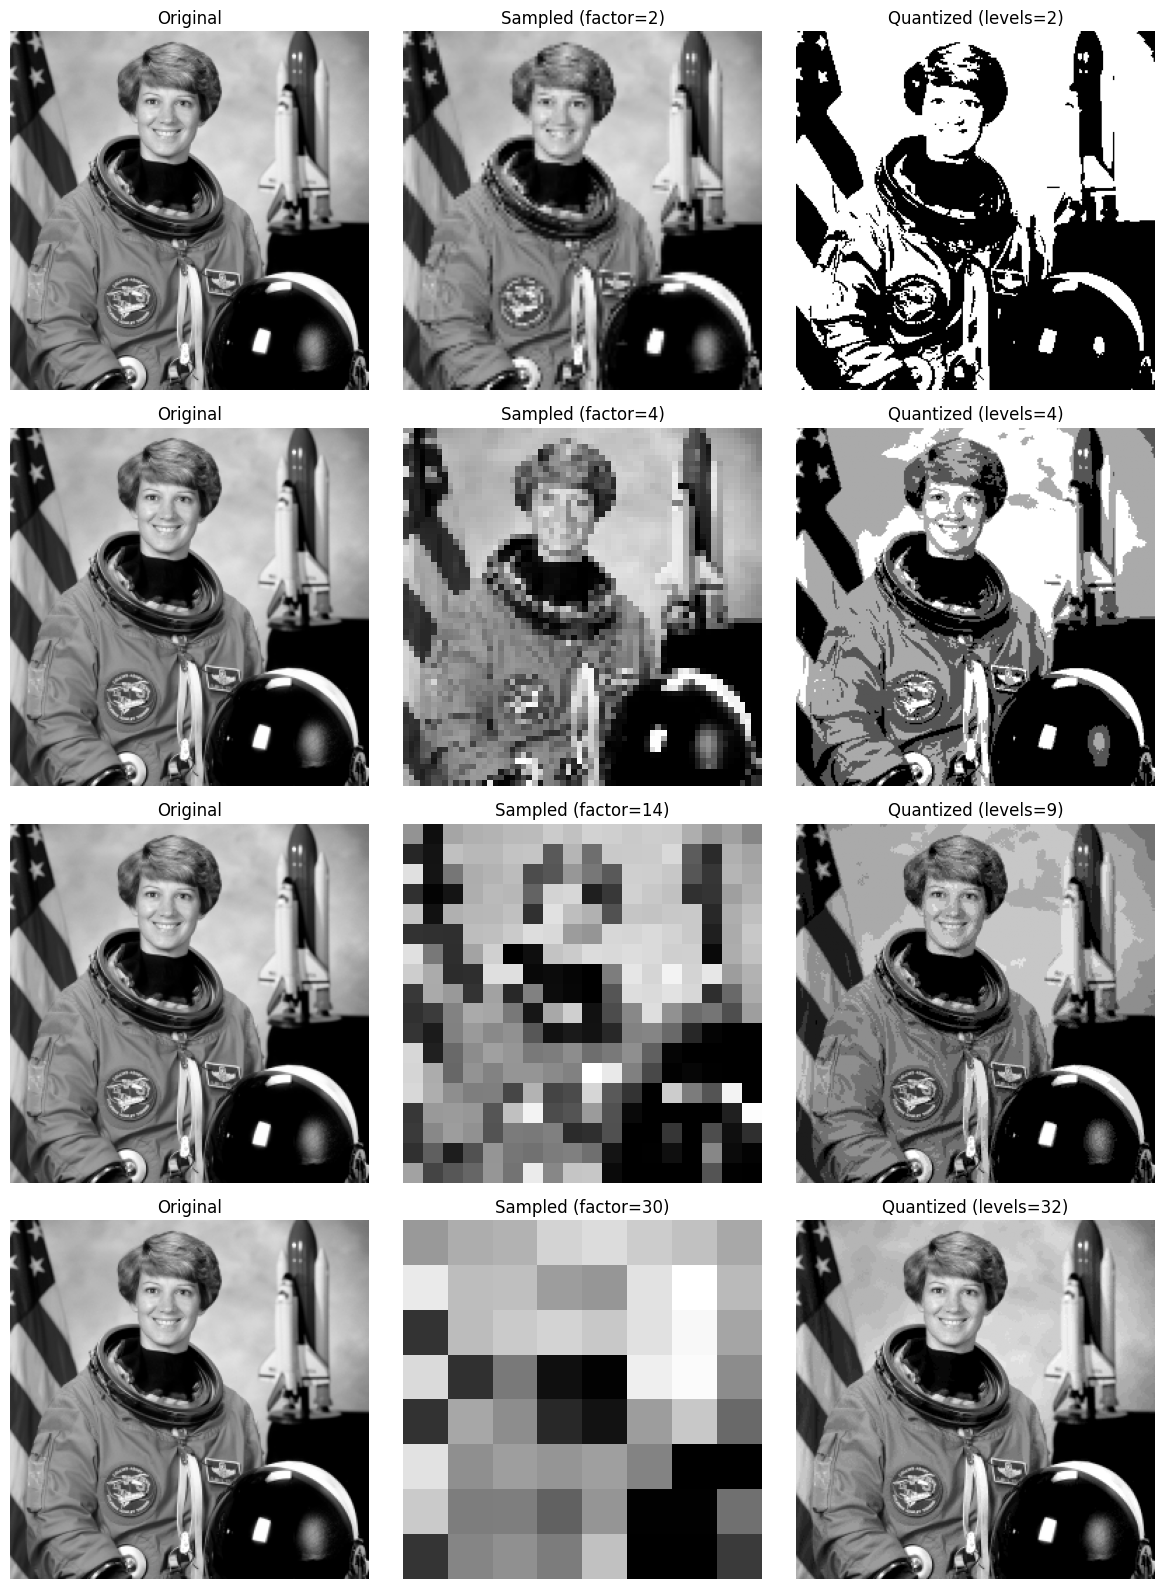

In [7]:
param_sets = [
    (2, 2),    # very light sampling, only 2 gray levels (near black & white)
    (4, 4),
    (14, 9),   # value given in the manual
    (30, 32),  # heavy downsampling, fine quantization
]

fig, axes = plt.subplots(len(param_sets), 3, figsize=(12, 4 * len(param_sets)))
for row, (factor, levels) in enumerate(param_sets):
    sampled = sample_image(original_image, factor)
    quantized = quantize_image(original_image, levels)

    axes[row, 0].imshow(original_image, cmap='gray'); axes[row, 0].set_title('Original'); axes[row, 0].axis('off')
    axes[row, 1].imshow(sampled, cmap='gray'); axes[row, 1].set_title(f'Sampled (factor={factor})'); axes[row, 1].axis('off')
    axes[row, 2].imshow(quantized, cmap='gray'); axes[row, 2].set_title(f'Quantized (levels={levels})'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


**Observation:**
- Increasing the **sampling factor** keeps fewer pixels, so the image becomes blockier and loses spatial detail (visible pixelation at factor=30).
- Decreasing the number of **quantization levels** keeps fewer gray shades, producing visible banding/posterization; at only 2 levels the image collapses into an almost pure black-and-white silhouette.
- The two effects are independent: sampling controls *spatial* resolution, quantization controls *gray-level* (intensity) resolution.

## Task #2 — Arithmetic and set/logical operations on two images

### a) Subtract two images and display the result

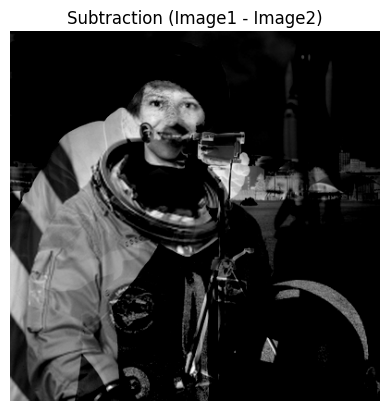

In [8]:
gray1 = im1arr.astype(np.int16)
gray2 = im2arr.astype(np.int16)

subtraction = np.clip(gray1 - gray2, 0, 255).astype(np.uint8)
plt.imshow(subtraction, cmap='gray'); plt.title('Subtraction (Image1 - Image2)'); plt.axis('off'); plt.show()


### b) Add one image with a constant value of 175 and display it

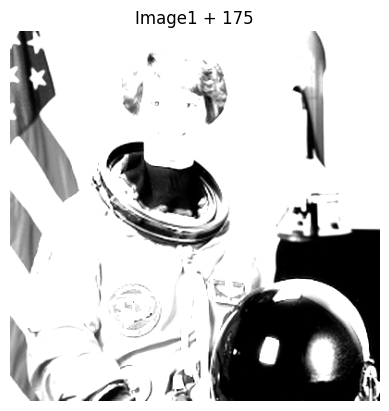

In [9]:
add_constant = np.clip(gray1 + 175, 0, 255).astype(np.uint8)
plt.imshow(add_constant, cmap='gray'); plt.title('Image1 + 175'); plt.axis('off'); plt.show()


### c) Set difference on two grayscale images (A − B = A AND NOT B)

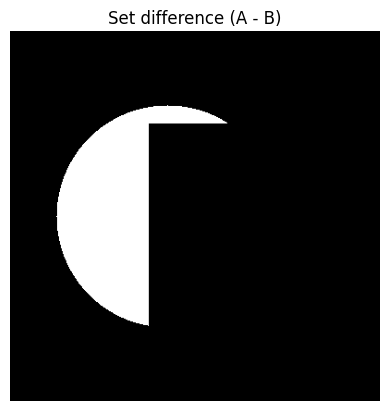

In [10]:
setA = im3arr
setB = im4arr

set_difference = cv2.bitwise_and(setA, cv2.bitwise_not(setB))
plt.imshow(set_difference, cmap='gray'); plt.title('Set difference (A - B)'); plt.axis('off'); plt.show()


### d) Symmetric difference on two grayscale images (A XOR B)

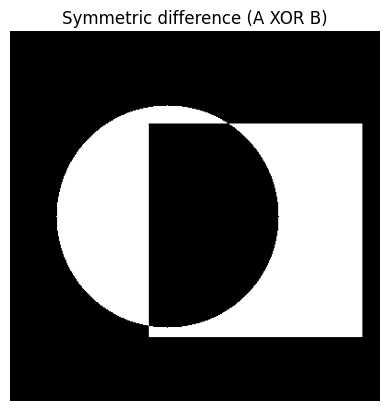

In [11]:
symmetric_difference = cv2.bitwise_xor(setA, setB)
plt.imshow(symmetric_difference, cmap='gray'); plt.title('Symmetric difference (A XOR B)'); plt.axis('off'); plt.show()


### e) Intersection of two grayscale images (A AND B)

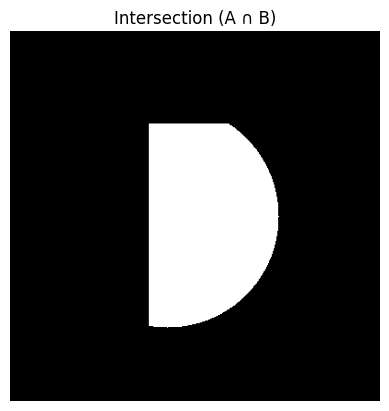

In [12]:
intersection = cv2.bitwise_and(setA, setB)
plt.imshow(intersection, cmap='gray'); plt.title('Intersection (A ∩ B)'); plt.axis('off'); plt.show()


**Summary of set/logical operations:**

| Operation | Formula | Meaning |
|---|---|---|
| Union | `A \| B` | pixels that are in A **or** B |
| Intersection | `A & B` | pixels that are in **both** A and B |
| Set difference (A − B) | `A & (~B)` | pixels in A but **not** in B |
| Symmetric difference | `A ^ B` | pixels in A or B but **not** in both |